## 1. Import Libraries và Cấu hình

In [ ]:
# Cài đặt thư viện OpenAI nếu chưa có
# !pip install openai

In [ ]:
import pandas as pd
import numpy as np
import time
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ML Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

# OpenAI SDK (dùng cho API bên thứ 3)
from openai import OpenAI
from rapidfuzz import fuzz

# --- CẤU HÌNH ---
# ⚠️ THAY API KEY CỦA BẠN VÀO ĐÂY (API key từ pinkyne.com)
API_KEY = "your-api-key"  # <-- Thay bằng API key từ pinkyne.com
BASE_URL = "https://api.pinkyne.com/v1"

# Model Gemini (qua API bên thứ 3)
MODEL_NAME = "gemini-2.5-flash"  # Hoặc tên model tương ứng trên pinkyne

# File paths
INPUT_CSV = "eval_level1_875.csv"
OUTPUT_CSV = "eval_gemini_level1_results.csv"
CHECKPOINT_CSV = "eval_gemini_checkpoint.csv"  # File lưu tiến trình

# === RATE LIMIT CONFIG (API bên thứ 3 thường ít limit hơn) ===
BATCH_SIZE = 20                    # Tăng lên vì ít bị limit hơn
DELAY_BETWEEN_REQUESTS = 2.0       # Giảm xuống vì API bên thứ 3
DELAY_BETWEEN_BATCHES = 30.0       # Giảm xuống
MAX_RETRIES = 5                    # Số lần retry khi gặp lỗi
RETRY_DELAY = 30                   # Giây chờ khi retry

# Sampling (đặt None để chạy toàn bộ 875 câu)
SAMPLE_SIZE = None  # None = chạy toàn bộ dataset
START_INDEX = 0     # Bắt đầu từ index nào (tự động skip nếu có checkpoint)

print("✅ Import thành công!")
print(f"📌 Model: {MODEL_NAME}")
print(f"📌 Base URL: {BASE_URL}")
print(f"📌 Dataset: {INPUT_CSV}")
print(f"\n⚙️ Rate Limit Config (API bên thứ 3):")
print(f"   - Batch size: {BATCH_SIZE} requests/batch")
print(f"   - Delay giữa requests: {DELAY_BETWEEN_REQUESTS}s")
print(f"   - Delay giữa batches: {DELAY_BETWEEN_BATCHES}s")
print(f"   - Max retries: {MAX_RETRIES}, retry delay: {RETRY_DELAY}s")

✅ Import thành công!
📌 Model: gemini-2.5-flash
📌 Dataset: eval_level1_875.csv


## 2. Khởi tạo OpenAI Client (API bên thứ 3)

In [ ]:
# Hàm tạo/reset client
def create_client():
    """Tạo mới OpenAI client với base URL của bên thứ 3"""
    return OpenAI(
        api_key=API_KEY,
        base_url=BASE_URL
    )

# Khởi tạo client lần đầu
client = create_client()

# Test kết nối
try:
    test_response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "user", "content": "Xin chào, bạn là ai?"}
        ],
        max_tokens=100
    )
    print("✅ Kết nối API thành công!")
    print(f"📝 Test response: {test_response.choices[0].message.content[:100]}...")
except Exception as e:
    print(f"❌ Lỗi kết nối: {e}")
    print("⚠️ Vui lòng kiểm tra lại API key và Base URL!")

✅ Kết nối Gemini API thành công!
📝 Test response: Chào bạn! Tôi là một mô hình ngôn ngữ lớn, được huấn luyện bởi Google....


## 3. Định nghĩa hàm gọi API (OpenAI SDK)

In [ ]:
def call_api_with_retry(messages, max_retries=MAX_RETRIES):
    """
    Gọi API với xử lý retry tự động khi gặp lỗi.
    Sử dụng OpenAI SDK với base URL của bên thứ 3.
    """
    global client
    
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=messages,
                max_tokens=500,
                temperature=0.3  # Giảm temperature để kết quả ổn định hơn
            )
            return response.choices[0].message.content
            
        except Exception as e:
            error_msg = str(e).lower()
            
            # Xử lý rate limit
            if "rate" in error_msg or "quota" in error_msg or "429" in error_msg:
                wait_time = RETRY_DELAY * (attempt + 1)
                print(f"\n⚠️ Rate limit! Đợi {wait_time}s rồi retry ({attempt+1}/{max_retries})...")
                time.sleep(wait_time)
                
                # Reset client
                print("🔄 Reset client...")
                client = create_client()
                time.sleep(2)
                continue
            
            # Resource exhausted
            if "resource" in error_msg or "exhausted" in error_msg:
                wait_time = 120  # 2 phút
                print(f"\n🔴 Resource exhausted! Đợi {wait_time}s...")
                time.sleep(wait_time)
                client = create_client()
                continue
            
            # Các lỗi khác
            if attempt < max_retries - 1:
                wait_time = RETRY_DELAY
                print(f"\n⚠️ Lỗi: {e}. Đợi {wait_time}s rồi retry ({attempt+1}/{max_retries})...")
                time.sleep(wait_time)
                continue
            else:
                return f"[ERROR] {str(e)}"
    
    return "[ERROR] Max retries exceeded"


def ask_mcq(question, option_a, option_b):
    """
    Hỏi một câu hỏi trắc nghiệm A/B qua API.
    """
    messages = [
        {
            "role": "system",
            "content": """Bạn là chuyên gia về điện ảnh và người nổi tiếng. 
Hãy trả lời câu hỏi trắc nghiệm một cách chính xác.
Trả lời theo format: "Đáp án: [A/B] - [Tên đáp án]. Lý do: [giải thích ngắn]"
"""
        },
        {
            "role": "user",
            "content": f"""CÂU HỎI: {question}

A) {option_a}
B) {option_b}

Hãy chọn đáp án đúng (A hoặc B):"""
        }
    ]
    
    return call_api_with_retry(messages)


print("✅ Định nghĩa hàm gọi API thành công!")

✅ Định nghĩa hàm gọi Gemini API thành công!


## 4. Định nghĩa hàm đánh giá câu trả lời

In [5]:
def evaluate_answer(bot_answer, ground_truth, option_a, option_b):
    """
    Đánh giá câu trả lời của Gemini với ground_truth.
    
    Logic:
    - ground_truth là TÊN ĐÚNG (ví dụ: "Elle Macpherson")
    - Kiểm tra xem bot_answer có chứa ground_truth không
    - Dùng rapidfuzz để xử lý trường hợp tên gần giống
    
    Returns: 1 nếu đúng, 0 nếu sai
    """
    # Xử lý trường hợp lỗi
    if bot_answer.startswith("[ERROR]"):
        return 0
    
    bot_ans_lower = bot_answer.lower()
    gt_lower = ground_truth.lower()
    opt_a_lower = option_a.lower()
    opt_b_lower = option_b.lower()
    
    # Check 1: Bot trả lời chứa ground_truth (exact match)
    if gt_lower in bot_ans_lower:
        return 1
    
    # Check 2: Dùng fuzzy matching với ngưỡng cao
    score = fuzz.partial_ratio(gt_lower, bot_ans_lower)
    if score >= 85:
        return 1
    
    # Check 3: Bot chọn đáp án sai (chứa option còn lại)
    wrong_option = opt_a_lower if gt_lower == opt_b_lower else opt_b_lower
    
    # Nếu bot chứa đáp án sai VÀ không chứa đáp án đúng -> Sai
    if wrong_option in bot_ans_lower and gt_lower not in bot_ans_lower:
        return 0
    
    # Check 4: Bot trả lời A/B trực tiếp
    correct_letter = "a" if gt_lower == opt_a_lower else "b"
    wrong_letter = "b" if correct_letter == "a" else "a"
    
    # Kiểm tra các pattern phổ biến
    correct_patterns = [
        f"đáp án: {correct_letter}",
        f"đáp án {correct_letter}",
        f"chọn {correct_letter}",
        f"là {correct_letter})",
        f"là {correct_letter}.",
    ]
    wrong_patterns = [
        f"đáp án: {wrong_letter}",
        f"đáp án {wrong_letter}",
        f"chọn {wrong_letter}",
        f"là {wrong_letter})",
        f"là {wrong_letter}.",
    ]
    
    for pattern in correct_patterns:
        if pattern in bot_ans_lower:
            return 1
    
    for pattern in wrong_patterns:
        if pattern in bot_ans_lower:
            return 0
    
    # Default: Không match được -> Sai
    return 0


print("✅ Định nghĩa hàm đánh giá câu trả lời thành công!")

✅ Định nghĩa hàm đánh giá câu trả lời thành công!


## 5. Load Dataset

In [6]:
# Load dataset
df = pd.read_csv(INPUT_CSV)
print(f"📊 Đã tải {len(df)} câu hỏi từ {INPUT_CSV}")
print(f"\n📋 Phân bố theo loại quan hệ:")
print(df['rel_type'].value_counts())

# Preview
df.head()

📊 Đã tải 808 câu hỏi từ eval_level1_875.csv

📋 Phân bố theo loại quan hệ:
rel_type
IS_PARTNER_OF         100
IS_PARENT_OF          100
ACTED_IN              100
PRODUCED              100
IS_SPOUSE_OF          100
HAS_GRANDPARENT_OF    100
DIRECTED              100
IS_SIBLING_OF         100
IS_CHILD_OF_DAD         6
IS_CHILD_OF_MOM         2
Name: count, dtype: int64


,level,rel_type,question,option_a,option_b,answer,ground_truth
0,1,IS_PARTNER_OF,Bạn đời của Kevin Costner là ai?,Vanessa Hudgens,Elle Macpherson,B,Elle Macpherson
1,1,IS_PARTNER_OF,Bạn đời của George Clooney là ai?,Kelly Preston,Kidada Jones,A,Kelly Preston
2,1,IS_PARENT_OF,Ai là con của Tom Hanks?,E. A. Hanks,Grace Cummings,A,E. A. Hanks
3,1,ACTED_IN,Ai đã tham gia vào bộ phim 'Sabotage'?,Connie Britton,Terrence Howard,B,Terrence Howard
4,1,IS_PARENT_OF,Ai là con của Robert De Niro?,Drena De Niro,Austin Jack Lynch,A,Drena De Niro


In [ ]:
# Lấy dữ liệu TUẦN TỰ (không random) để dễ resume
if SAMPLE_SIZE:
    df_eval = df.iloc[START_INDEX:START_INDEX + SAMPLE_SIZE].reset_index(drop=True)
    print(f"⚠️ Chạy trên {len(df_eval)} câu hỏi (từ index {START_INDEX} đến {START_INDEX + SAMPLE_SIZE - 1})")
else:
    df_eval = df.iloc[START_INDEX:].reset_index(drop=True)
    print(f"🚀 Chạy đánh giá trên {len(df_eval)} câu hỏi (từ index {START_INDEX})")

# Tính số batch
num_batches = (len(df_eval) + BATCH_SIZE - 1) // BATCH_SIZE
print(f"\n📊 Chia thành {num_batches} batches, mỗi batch {BATCH_SIZE} câu")

# Ước tính thời gian
time_per_batch = BATCH_SIZE * DELAY_BETWEEN_REQUESTS + DELAY_BETWEEN_BATCHES
estimated_time = num_batches * time_per_batch / 60
print(f"⏱️ Thời gian ước tính: ~{estimated_time:.1f} phút (~{estimated_time/60:.1f} giờ)")

# AUTO RESUME: Tự động tiếp tục từ checkpoint nếu có
if os.path.exists(CHECKPOINT_CSV):
    checkpoint_df = pd.read_csv(CHECKPOINT_CSV)
    print(f"\n💾 Tìm thấy checkpoint với {len(checkpoint_df)} kết quả đã lưu")
    print("🔄 Tự động tiếp tục từ checkpoint...")
    resume = True
else:
    checkpoint_df = None
    resume = False
    print("\n🆕 Bắt đầu mới từ đầu...")

⚠️ Chạy thử trên 100 câu hỏi
⏱️ Thời gian ước tính: ~16.7 phút (với delay 10.0s/request)


## 6. Chạy Đánh giá Gemini

In [ ]:
# === HOÀN TOÀN TỰ ĐỘNG - KHÔNG CẦN CAN THIỆP ===

# Khởi tạo hoặc load từ checkpoint
if resume and checkpoint_df is not None:
    results = checkpoint_df.to_dict('records')
    start_idx = len(results)
    print(f"📂 Tự động resume từ câu hỏi thứ {start_idx + 1}/{len(df_eval)}")
else:
    results = []
    start_idx = 0

# Đếm số lỗi
error_count = 0
current_batch = start_idx // BATCH_SIZE

# Thời gian bắt đầu
start_time = time.time()

print(f"\n{'='*60}")
print(f"🌙 BẮT ĐẦU ĐÁNH GIÁ TỰ ĐỘNG - LEVEL 1")
print(f"{'='*60}")
print(f"🤖 Model: {MODEL_NAME} (via {BASE_URL})")
print(f"📋 Từ câu {start_idx + 1} đến câu {len(df_eval)}")
print(f"📋 Config: {BATCH_SIZE} req/batch, {DELAY_BETWEEN_REQUESTS}s delay")
print(f"📋 Checkpoint tự động lưu sau mỗi batch")
print(f"{'='*60}\n")

# === VÒNG LẶP ĐÁNH GIÁ CHÍNH ===
for idx in tqdm(range(start_idx, len(df_eval)), desc="Đánh giá Level 1", initial=start_idx, total=len(df_eval)):
    row = df_eval.iloc[idx]
    question = row['question']
    ground_truth = row['ground_truth']
    option_a = row['option_a']
    option_b = row['option_b']
    rel_type = row['rel_type']
    
    # Kiểm tra nếu là đầu batch mới (trừ batch đầu tiên)
    batch_num = idx // BATCH_SIZE
    if batch_num > current_batch:
        current_batch = batch_num
        
        # Tính tiến độ
        elapsed = time.time() - start_time
        progress = (idx - start_idx) / (len(df_eval) - start_idx) * 100 if len(df_eval) > start_idx else 0
        remaining = (elapsed / (idx - start_idx + 1)) * (len(df_eval) - idx) if idx > start_idx else 0
        
        print(f"\n\n{'='*50}")
        print(f"🔄 BATCH {batch_num + 1}/{num_batches} | Tiến độ: {progress:.1f}%")
        print(f"⏱️ Đã chạy: {elapsed/60:.1f} phút | Còn lại: ~{remaining/60:.1f} phút")
        print(f"⏳ Nghỉ {DELAY_BETWEEN_BATCHES}s...")
        print(f"{'='*50}")
        
        time.sleep(DELAY_BETWEEN_BATCHES)
        
        # Reset client định kỳ
        client = create_client()
        time.sleep(2)
        print("✅ Đã reset client, tiếp tục...\n")
    
    try:
        # Gọi API
        bot_answer = ask_mcq(question, option_a, option_b)
        
        # Kiểm tra lỗi
        if bot_answer.startswith("[ERROR]"):
            error_count += 1
        
        # Đánh giá
        score = evaluate_answer(bot_answer, ground_truth, option_a, option_b)
        
    except Exception as e:
        bot_answer = f"[ERROR] {str(e)}"
        score = 0
        error_count += 1
        print(f"\n❌ Lỗi không xử lý được: {e}")
    
    # Lưu kết quả
    results.append({
        "question": question,
        "option_a": option_a,
        "option_b": option_b,
        "ground_truth": ground_truth,
        "bot_answer": bot_answer[:500] if bot_answer else "",
        "rel_type": rel_type,
        "score": score
    })
    
    # Lưu checkpoint sau mỗi batch
    if (idx + 1) % BATCH_SIZE == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_CSV, index=False, encoding='utf-8-sig')
        correct_so_far = sum(r['score'] for r in results)
        acc_so_far = correct_so_far / len(results) * 100
        print(f"💾 Checkpoint: {len(results)} câu | Accuracy: {acc_so_far:.1f}% | Errors: {error_count}")
    
    # Delay giữa các request trong batch
    if (idx + 1) % BATCH_SIZE != 0:
        time.sleep(DELAY_BETWEEN_REQUESTS)

# Lưu checkpoint cuối cùng
pd.DataFrame(results).to_csv(CHECKPOINT_CSV, index=False, encoding='utf-8-sig')

# Tổng kết
total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"🎉 HOÀN THÀNH ĐÁNH GIÁ!")
print(f"{'='*60}")
print(f"✅ Tổng số câu: {len(results)}")
print(f"⚠️ Số lỗi: {error_count}")
print(f"⏱️ Tổng thời gian: {total_time/60:.1f} phút ({total_time/3600:.2f} giờ)")
print(f"💾 Đã lưu vào: {CHECKPOINT_CSV}")

# Tính y_true, y_pred cho metrics
y_true = [1] * len(results)
y_pred = [r['score'] for r in results]


🔄 Bắt đầu đánh giá Gemini...


Đánh giá Gemini:   0%|          | 0/100 [00:00<?, ?it/s]

Đánh giá Gemini:  19%|█▉        | 19/100 [04:55<18:29, 13.70s/it]

⚠️ Rate limit! Đợi 5s rồi retry (1/3)...
⚠️ Rate limit! Đợi 10s rồi retry (2/3)...
⚠️ Rate limit! Đợi 10s rồi retry (2/3)...
⚠️ Rate limit! Đợi 15s rồi retry (3/3)...
⚠️ Rate limit! Đợi 15s rồi retry (3/3)...


Đánh giá Gemini:  20%|██        | 20/100 [05:36<29:12, 21.90s/it]

...

⚠️ Rate limit! Đợi 5s rồi retry (1/3)...
⚠️ Rate limit! Đợi 10s rồi retry (2/3)...
⚠️ Rate limit! Đợi 10s rồi retry (2/3)...
⚠️ Rate limit! Đợi 15s rồi retry (3/3)...
⚠️ Rate limit! Đợi 15s rồi retry (3/3)...


Đánh giá Gemini:  99%|█████████▉| 99/100 [58:30<00:41, 41.17s/it]

⚠️ Rate limit! Đợi 5s rồi retry (1/3)...
⚠️ Rate limit! Đợi 10s rồi retry (2/3)...
⚠️ Rate limit! Đợi 10s rồi retry (2/3)...
⚠️ Rate limit! Đợi 15s rồi retry (3/3)...
⚠️ Rate limit! Đợi 15s rồi retry (3/3)...


Đánh giá Gemini: 100%|██████████| 100/100 [59:11<00:00, 35.52s/it]


✅ Hoàn thành đánh giá 100 câu hỏi!
⚠️ Số lỗi gặp phải: 78


## 7. Tính toán và Hiển thị Metrics

In [9]:
# Chuyển kết quả sang DataFrame
results_df = pd.DataFrame(results)

# === TÍNH TOÁN METRICS ===
total = len(results_df)
correct = results_df['score'].sum()

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision, Recall, F1 (binary)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# === HIỂN THỊ KẾT QUẢ ===
print("=" * 60)
print("📊 KẾT QUẢ ĐÁNH GIÁ GEMINI 2.5 FLASH - LEVEL 1")
print("=" * 60)
print(f"📁 Dataset: {INPUT_CSV}")
print(f"🤖 Model: {MODEL_NAME}")
print(f"📝 Tổng số câu hỏi: {total}")
print(f"✅ Số câu đúng: {correct}")
print(f"❌ Số câu sai: {total - correct}")
print("-" * 60)
print(f"🎯 ACCURACY:  {accuracy * 100:.2f}%")
print(f"📐 PRECISION: {precision * 100:.2f}%")
print(f"📏 RECALL:    {recall * 100:.2f}%")
print(f"⚖️  F1-SCORE:  {f1 * 100:.2f}%")
print("=" * 60)

# Tạo summary DataFrame
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [f"{accuracy*100:.2f}%", f"{precision*100:.2f}%", f"{recall*100:.2f}%", f"{f1*100:.2f}%"]
})
metrics_summary

📊 KẾT QUẢ ĐÁNH GIÁ GEMINI 2.5 FLASH - LEVEL 1
📁 Dataset: eval_level1_875.csv
🤖 Model: gemini-2.5-flash
📝 Tổng số câu hỏi: 100
✅ Số câu đúng: 22
❌ Số câu sai: 78
------------------------------------------------------------
🎯 ACCURACY:  22.00%
📐 PRECISION: 100.00%
📏 RECALL:    22.00%
⚖️  F1-SCORE:  36.07%


,Metric,Value
0,Accuracy,22.00%
1,Precision,100.00%
2,Recall,22.00%
3,F1-Score,36.07%


## 8. Phân tích theo Loại Quan hệ (Relationship Type)

In [10]:
# Tính accuracy theo từng loại quan hệ
rel_stats = results_df.groupby('rel_type').agg({
    'score': ['sum', 'count', 'mean']
}).round(4)
rel_stats.columns = ['Correct', 'Total', 'Accuracy']
rel_stats['Accuracy'] = (rel_stats['Accuracy'] * 100).round(2)
rel_stats = rel_stats.sort_values('Accuracy', ascending=False)

print("📊 ACCURACY THEO LOẠI QUAN HỆ (GEMINI):")
print("-" * 50)
rel_stats

📊 ACCURACY THEO LOẠI QUAN HỆ (GEMINI):
--------------------------------------------------


,Correct,Total,Accuracy
rel_type,,,
IS_CHILD_OF_DAD,1,1,100.00
HAS_GRANDPARENT_OF,5,13,38.46
IS_PARENT_OF,6,16,37.50
PRODUCED,2,10,20.00
DIRECTED,3,17,17.65
ACTED_IN,2,12,16.67
IS_SPOUSE_OF,1,7,14.29
IS_PARTNER_OF,1,11,9.09
IS_SIBLING_OF,1,12,8.33


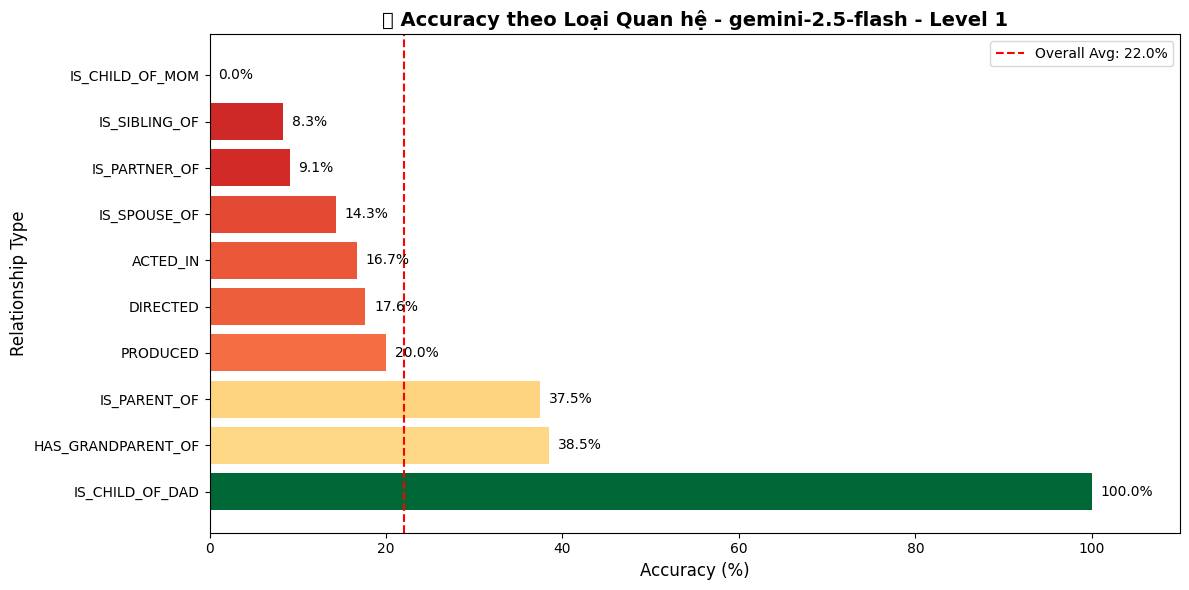

In [11]:
# Vẽ biểu đồ Accuracy theo loại quan hệ
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.RdYlGn(rel_stats['Accuracy'] / 100)
bars = ax.barh(rel_stats.index, rel_stats['Accuracy'], color=colors)

# Thêm label trên mỗi bar
for bar, acc in zip(bars, rel_stats['Accuracy']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{acc:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_ylabel('Relationship Type', fontsize=12)
ax.set_title(f'📊 Accuracy theo Loại Quan hệ - {MODEL_NAME} - Level 1', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
ax.axvline(x=accuracy*100, color='red', linestyle='--', label=f'Overall Avg: {accuracy*100:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('gemini_level1_accuracy_by_reltype.png', dpi=150)
plt.show()

## 9. Lưu kết quả

In [12]:
# Lưu kết quả chi tiết
results_df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"💾 Đã lưu kết quả chi tiết vào: {OUTPUT_CSV}")

# Lưu metrics summary
metrics_full = {
    'metric': ['accuracy', 'precision', 'recall', 'f1_score', 'total_questions', 'correct_answers', 'error_count'],
    'value': [accuracy, precision, recall, f1, total, correct, error_count]
}
pd.DataFrame(metrics_full).to_csv('eval_gemini_level1_metrics.csv', index=False)
print("💾 Đã lưu metrics vào: eval_gemini_level1_metrics.csv")

💾 Đã lưu kết quả chi tiết vào: eval_gemini_level1_results.csv
💾 Đã lưu metrics vào: eval_gemini_level1_metrics.csv


## 10. Phân tích một số câu trả lời

In [13]:
# Xem một số câu đúng
print("✅ MẪU CÂU TRẢ LỜI ĐÚNG:")
print("=" * 80)
correct_samples = results_df[results_df['score'] == 1].head(3)

for idx, row in correct_samples.iterrows():
    print(f"\n📌 Câu hỏi: {row['question']}")
    print(f"   ✅ Đáp án đúng: {row['ground_truth']}")
    print(f"   🤖 Gemini: {row['bot_answer'][:200]}...")
    print("-" * 80)

✅ MẪU CÂU TRẢ LỜI ĐÚNG:

📌 Câu hỏi: Ai là con của Kevin Kline?
   ✅ Đáp án đúng: Owen Kline
   🤖 Gemini: Đáp án: A - Owen Kline. Lý do: Owen Kline là con trai của nam diễn viên Kevin Kline và nữ diễn viên Phoebe Cates....
--------------------------------------------------------------------------------

📌 Câu hỏi: Ai là con của Michael Douglas?
   ✅ Đáp án đúng: Cameron Douglas
   🤖 Gemini: Đáp án: B - Cameron Douglas. Lý do: Cameron Douglas là con trai của tài tử Michael Douglas. Julie Pacino là con gái của tài tử Al Pacino....
--------------------------------------------------------------------------------

📌 Câu hỏi: Ai là đạo diễn của bộ phim 'Live in Bucharest: The Dangerous Tour'?
   ✅ Đáp án đúng: Michael Jackson
   🤖 Gemini: Đáp án: A - Michael Jackson. Lý do: 'Live in Bucharest: The Dangerous Tour' là một bộ phim concert ghi lại buổi biểu diễn của Michael Jackson trong chuyến lưu diễn Dangerous World Tour. Mặc dù có đạo ...
------------------------------------------------------

In [14]:
# Phân tích các câu trả lời sai
wrong_answers = results_df[results_df['score'] == 0]
print(f"\n❌ PHÂN TÍCH CÂU TRẢ LỜI SAI ({len(wrong_answers)} câu):")
print("=" * 80)

# Hiển thị 5 câu sai đầu tiên
for idx, row in wrong_answers.head(5).iterrows():
    print(f"\n📌 Câu hỏi: {row['question']}")
    print(f"   ✅ Đáp án đúng: {row['ground_truth']}")
    print(f"   ❌ Gemini: {row['bot_answer'][:200]}...")
    print(f"   🏷️ Loại: {row['rel_type']}")
    print("-" * 80)


❌ PHÂN TÍCH CÂU TRẢ LỜI SAI (78 câu):

📌 Câu hỏi: Ai là đạo diễn của bộ phim 'Jaws'?
   ✅ Đáp án đúng: Steven Spielberg
   ❌ Gemini: [ERROR] Max retries exceeded...
   🏷️ Loại: DIRECTED
--------------------------------------------------------------------------------

📌 Câu hỏi: Ai là con của Peter Fonda?
   ✅ Đáp án đúng: Justin Fonda
   ❌ Gemini: [ERROR] Max retries exceeded...
   🏷️ Loại: IS_PARENT_OF
--------------------------------------------------------------------------------

📌 Câu hỏi: Ai đã tham gia vào bộ phim 'The Expendables 2'?
   ✅ Đáp án đúng: Sylvester Stallone
   ❌ Gemini: [ERROR] Max retries exceeded...
   🏷️ Loại: ACTED_IN
--------------------------------------------------------------------------------

📌 Câu hỏi: Ai là con của Joe Frazier?
   ✅ Đáp án đúng: Marvis Frazier
   ❌ Gemini: [ERROR] Max retries exceeded...
   🏷️ Loại: IS_PARENT_OF
--------------------------------------------------------------------------------

📌 Câu hỏi: Ông/Bà của Mike Myers là ai?
   

## 11. Tổng kết

In [15]:
# Tổng kết cuối cùng
print("\n" + "=" * 60)
print("🏆 TỔNG KẾT ĐÁNH GIÁ GEMINI 2.5 FLASH")
print("=" * 60)
print(f"""
🤖 Model: {MODEL_NAME}
📁 Dataset: {INPUT_CSV}
📝 Số câu hỏi: {total}
⚠️ Số lỗi: {error_count}

┌──────────────┬─────────────┐
│ Metric       │ Value       │
├──────────────┼─────────────┤
│ Accuracy     │ {accuracy*100:>8.2f}%  │
│ Precision    │ {precision*100:>8.2f}%  │
│ Recall       │ {recall*100:>8.2f}%  │
│ F1-Score     │ {f1*100:>8.2f}%  │
└──────────────┴─────────────┘

📈 Loại quan hệ tốt nhất: {rel_stats.index[0]} ({rel_stats['Accuracy'].iloc[0]:.1f}%)
📉 Loại quan hệ kém nhất: {rel_stats.index[-1]} ({rel_stats['Accuracy'].iloc[-1]:.1f}%)

✅ Đánh giá hoàn tất!

📋 So sánh với Iterative Graph RAG:
   - Xem file: eval_level1_metrics.csv (Iterative RAG)
   - Xem file: eval_gemini_level1_metrics.csv (Gemini)
""")


🏆 TỔNG KẾT ĐÁNH GIÁ GEMINI 2.5 FLASH

🤖 Model: gemini-2.5-flash
📁 Dataset: eval_level1_875.csv
📝 Số câu hỏi: 100
⚠️ Số lỗi: 78

┌──────────────┬─────────────┐
│ Metric       │ Value       │
├──────────────┼─────────────┤
│ Accuracy     │    22.00%  │
│ Precision    │   100.00%  │
│ Recall       │    22.00%  │
│ F1-Score     │    36.07%  │
└──────────────┴─────────────┘

📈 Loại quan hệ tốt nhất: IS_CHILD_OF_DAD (100.0%)
📉 Loại quan hệ kém nhất: IS_CHILD_OF_MOM (0.0%)

✅ Đánh giá hoàn tất!

📋 So sánh với Iterative Graph RAG:
   - Xem file: eval_level1_metrics.csv (Iterative RAG)
   - Xem file: eval_gemini_level1_metrics.csv (Gemini)

